In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE
df = pd.read_csv(r'C:\Users\saksh\Dropbox\PROJECTS\Project_1\Data\creditcard.csv')
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (284807, 31)


C:\Users\saksh\AppData\Local\Temp\ipykernel_24664\3950910100.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=colors)


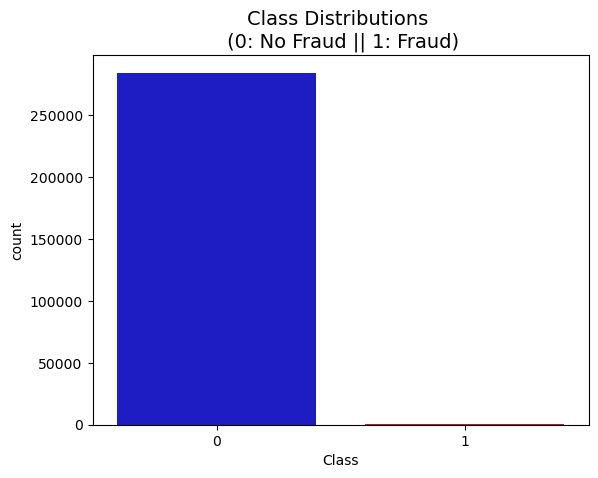

Percentage of Fraudulent Transactions: 0.17%


In [6]:
colors = ["#0101DF", "#DF0101"]
sns.countplot(x='Class', data=df, palette=colors)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)
plt.show()

fraud_pct = (df['Class'].value_counts()[1] / len(df)) * 100
print(f"Percentage of Fraudulent Transactions: {fraud_pct:.2f}%")

In [ ]:

std_scaler = StandardScaler()

df['scaled_amount'] = std_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = std_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
print(f"Before SMOTE, counts of label '1': {sum(y_train == 1)}")

sm = SMOTE(sampling_strategy='minority', random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"After SMOTE, counts of label '1': {sum(y_train_res == 1)}")

Before SMOTE, counts of label '1': 394
After SMOTE, counts of label '1': 227451


In [ ]:

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)

y_pred = rf_model.predict(X_test)

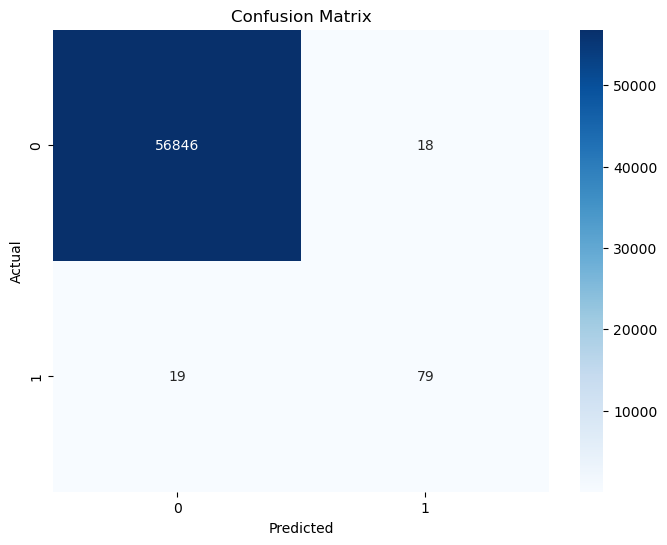

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962



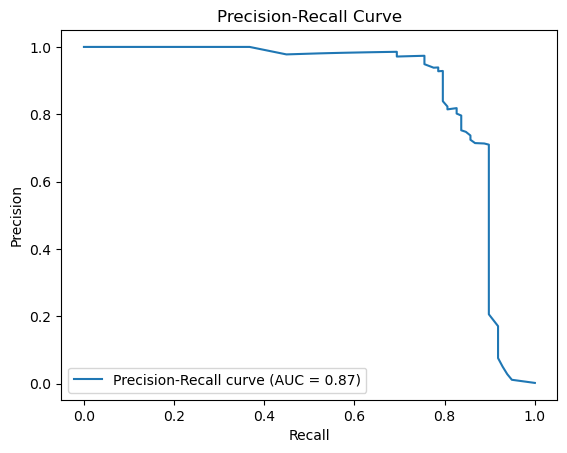

In [10]:

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


print(classification_report(y_test, y_pred))


precision, recall, thresholds = precision_recall_curve(y_test, rf_model.predict_proba(X_test)[:,1])
pr_auc = auc(recall, precision)

plt.plot(recall, precision, label=f'Precision-Recall curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

In [14]:
import joblib

joblib.dump(rf_model, r'C:\Users\saksh\Dropbox\PROJECTS\Project_1\Src\fraud_model_v1.pkl')


joblib.dump(std_scaler, r'C:\Users\saksh\Dropbox\PROJECTS\Project_1\Src\scaler.pkl')

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [16]:
def real_time_check(transaction_features):
    """
    Simulates checking a new incoming transaction.
    """
    
    model = joblib.load(r'C:\Users\saksh\Dropbox\PROJECTS\Project_1\Src\fraud_model_v1.pkl')
    scaler = joblib.load(r'C:\Users\saksh\Dropbox\PROJECTS\Project_1\Src\scaler.pkl')

    proba = model.predict_proba(transaction_features)[0][1]
    
    if proba > 0.8:
        return f"🚨 FRAUD ALERT: {proba*100:.2f}% Probability"
    return f"✅ Transaction Approved: {proba*100:.2f}% Probability"

sample = X_test.iloc[0].values.reshape(1, -1)
print(real_time_check(sample))

✅ Transaction Approved: 0.00% Probability


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [20]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import joblib
import numpy as np

model = joblib.load(r'C:\Users\saksh\Dropbox\PROJECTS\Project_1\Src\fraud_model_v1.pkl')
scaler = joblib.load(r'C:\Users\saksh\Dropbox\PROJECTS\Project_1\Src\scaler.pkl')

style = {'description_width': 'initial'}
title = widgets.HTML("<h2>🛡️ Financial Fraud Detection System</h2>")
amount_input = widgets.FloatText(value=100.0, description="Transaction Amount ($):", style=style)
time_input = widgets.IntText(value=0, description="Time (Seconds):", style=style)
predict_button = widgets.Button(description="Analyze Transaction", button_style='primary')
output = widgets.Output()

def on_predict_clicked(b):
    with output:
        clear_output()
       
        v_features = [0.0] * 28
        input_data = np.array(v_features + [amount_input.value, time_input.value]).reshape(1, -1)
        
       
        proba = model.predict_proba(input_data)[0][1]
        
        if proba > 0.8:
            print(f"🚨 HIGH RISK: {proba*100:.1f}% Probability. [BLOCK]")
        elif proba > 0.5:
            print(f"⚠️ MEDIUM RISK: {proba*100:.1f}% Probability. [REVIEW]")
        else:
            print(f"✅ LOW RISK: {proba*100:.1f}% Probability. [APPROVE]")

predict_button.on_click(on_predict_clicked)

ui = widgets.VBox([title, amount_input, time_input, predict_button, output])
display(ui)